In [134]:
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
df = pd.read_csv("../data/processed/clean_data.csv")

In [136]:
df.head()

,Unnamed: 0,incident_key,occur_date,occur_time,boro,precinct,jurisdiction_code,statistical_murder_flag,perp_age_group,perp_sex,...,:created_at,:updated_at,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,location_desc,loc_of_occur_desc,loc_classfctn_desc
0,0,209281500,2020-02-08T00:00:00.000,12:13:00,QUEENS,115,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,21.0,73.0,14510.0,65.0,NaN,NaN,NaN
1,1,209281497,2020-02-08T00:00:00.000,02:20:00,BROOKLYN,76,0.0,True,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,7.0,48.0,13514.0,14.0,NaN,NaN,NaN
2,2,209281498,2020-02-07T00:00:00.000,22:50:00,BROOKLYN,75,0.0,False,25-44,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,2.0,37.0,47.0,17214.0,45.0,NaN,NaN,NaN
3,3,209099251,2020-02-05T00:00:00.000,04:02:00,QUEENS,101,0.0,False,NaN,NaN,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,3.0,47.0,59.0,20529.0,51.0,MULTI DWELL - APT BUILD,NaN,NaN
4,4,209098666,2020-02-05T00:00:00.000,23:13:00,MANHATTAN,34,0.0,False,18-24,M,...,2024-04-23T13:36:19.239Z,2024-04-23T13:36:30.560Z,4.0,39.0,22.0,13098.0,47.0,MULTI DWELL - APT BUILD,NaN,NaN


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29000 entries, 0 to 28999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   29000 non-null  int64  
 1   incident_key                 29000 non-null  int64  
 2   occur_date                   29000 non-null  str    
 3   occur_time                   29000 non-null  str    
 4   boro                         29000 non-null  str    
 5   precinct                     29000 non-null  int64  
 6   jurisdiction_code            28998 non-null  float64
 7   statistical_murder_flag      29000 non-null  bool   
 8   perp_age_group               19703 non-null  str    
 9   perp_sex                     19704 non-null  str    
 10  perp_race                    19704 non-null  str    
 11  vic_age_group                29000 non-null  str    
 12  vic_sex                      29000 non-null  str    
 13  vic_race                   

In [138]:
# DILLEMA: if the .isnull() counts values like "unknown", "null" 
# in the dataframe as NaN
df.isnull().sum()

Unnamed: 0                         0
incident_key                       0
occur_date                         0
occur_time                         0
boro                               0
precinct                           0
jurisdiction_code                  2
statistical_murder_flag            0
perp_age_group                  9297
perp_sex                        9296
perp_race                       9296
vic_age_group                      0
vic_sex                            0
vic_race                           0
x_coord_cd                         0
y_coord_cd                         0
latitude                          97
longitude                         97
geocoded_column                   97
:id                                0
:version                           0
:created_at                        0
:updated_at                        0
:@computed_region_yeji_bk3q       97
:@computed_region_92fq_4b7q       97
:@computed_region_sbqj_enih       97
:@computed_region_efsh_h5xi      138
:

SELECTION OF COLUMNS FOR ANALYSIS AND CLEANING OF MALFORMED VALUES

In [139]:
# Represent both dataframe with NAN values and after dropping NAN value
age_df = df[[
    'vic_age_group',
    'perp_age_group',
    'occur_date'
]]
age_df = age_df[(age_df['vic_age_group'] != 'UNKNOWN' ) &
                (age_df['perp_age_group'] != 'UNKNOWN') ]

# age_df = age_df.dropna()
# print the age dataframe with the malformed values cleaned from the it.
age_df.info

<bound method DataFrame.info of       vic_age_group perp_age_group               occur_date
0             25-44          25-44  2020-02-08T00:00:00.000
1             25-44          25-44  2020-02-08T00:00:00.000
2             25-44          25-44  2020-02-07T00:00:00.000
3             25-44            NaN  2020-02-05T00:00:00.000
4             18-24          18-24  2020-02-05T00:00:00.000
...             ...            ...                      ...
28995         25-44         (null)  2022-02-09T00:00:00.000
28996         25-44         (null)  2022-02-09T00:00:00.000
28997         18-24         (null)  2022-02-08T00:00:00.000
28998         25-44          25-44  2022-02-08T00:00:00.000
28999         25-44          18-24  2022-02-08T00:00:00.000

[26065 rows x 3 columns]>

In [140]:
age_df["occur_date"] = pd.to_datetime(age_df['occur_date'])
age_df['year'] = age_df['occur_date'].dt.year
age_df.head()

,vic_age_group,perp_age_group,occur_date,year
0,25-44,25-44,2020-02-08,2020
1,25-44,25-44,2020-02-08,2020
2,25-44,25-44,2020-02-07,2020
3,25-44,NaN,2020-02-05,2020
4,18-24,18-24,2020-02-05,2020


Victims and Prepetrators Age Group in NYC Shooting Comparisons

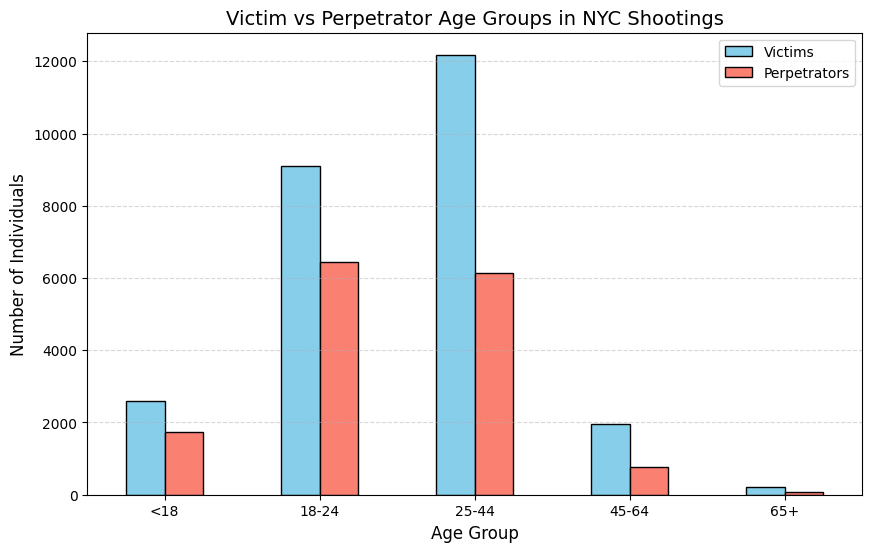

In [141]:
# Count the victim and perpetrator age groups
victim_counts = age_df["vic_age_group"].value_counts()
perp_counts = age_df["perp_age_group"].value_counts()

# Combine both into one dataframe
age_compare = pd.DataFrame({
    "Victims": victim_counts,
    "Perpetrators": perp_counts
})

age_order = ['<18', '18-24', '25-44', '45-64', '65+']

age_compare = age_compare.reindex(age_order)

age_compare

# Create the visualization
age_compare.plot(
    kind='bar',
    figsize=(10,6),
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.title("Victim vs Perpetrator Age Groups in NYC Shootings", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Individuals", fontsize=12)

plt.xticks(rotation=0)
plt.legend(
    labels=["Victims", "Perpetrators"]
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show the graph
plt.show()


VICTIM AGE GROUP TRENDS OVER TIME

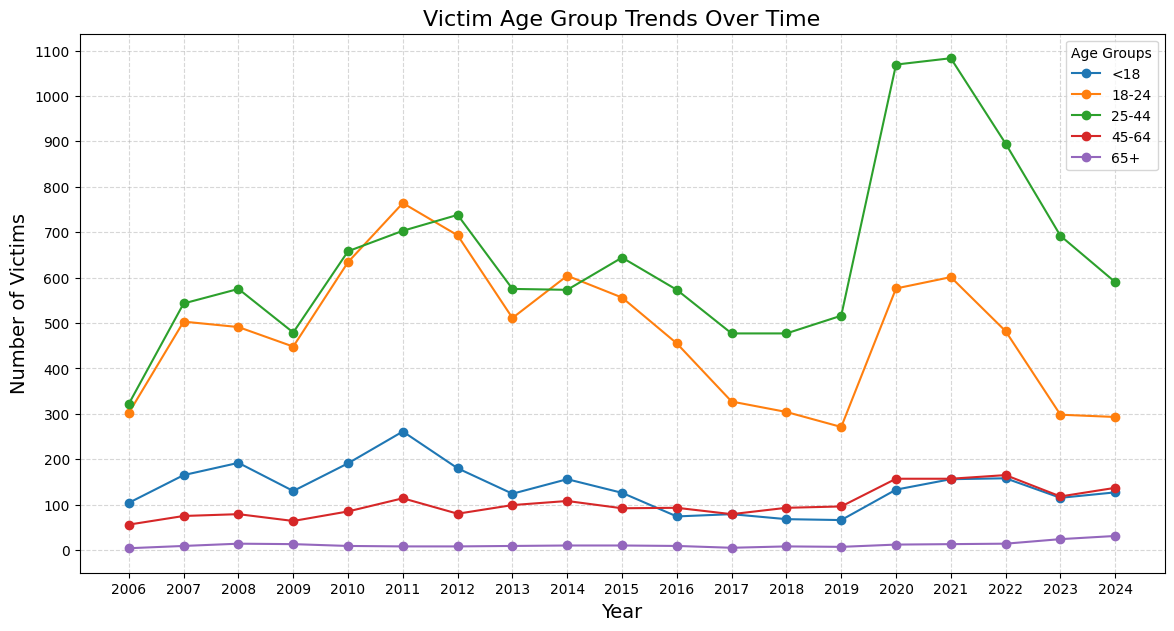

In [142]:
age_order = ['<18', '18-24', '25-44', '45-64', '65+']

victim_trends = age_df.groupby([
    "year",
    "vic_age_group"
]).size().unstack(fill_value=0)

victim_trends = victim_trends.reindex(columns=age_order)
all_years = sorted(age_df["year"].dropna().unique())

victim_trends.plot(
    kind="line",
    figsize=(14, 7),
    marker="o"
)

plt.title("Victim Age Group Trends Over Time", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Victims", fontsize=14)

plt.xticks(all_years)
plt.yticks(range(0,1200,100))
plt.legend(title="Age Groups")

plt.grid(True, linestyle="--", alpha=0.5)

# Show graph
plt.show()

UNDER-18 VICTIMS

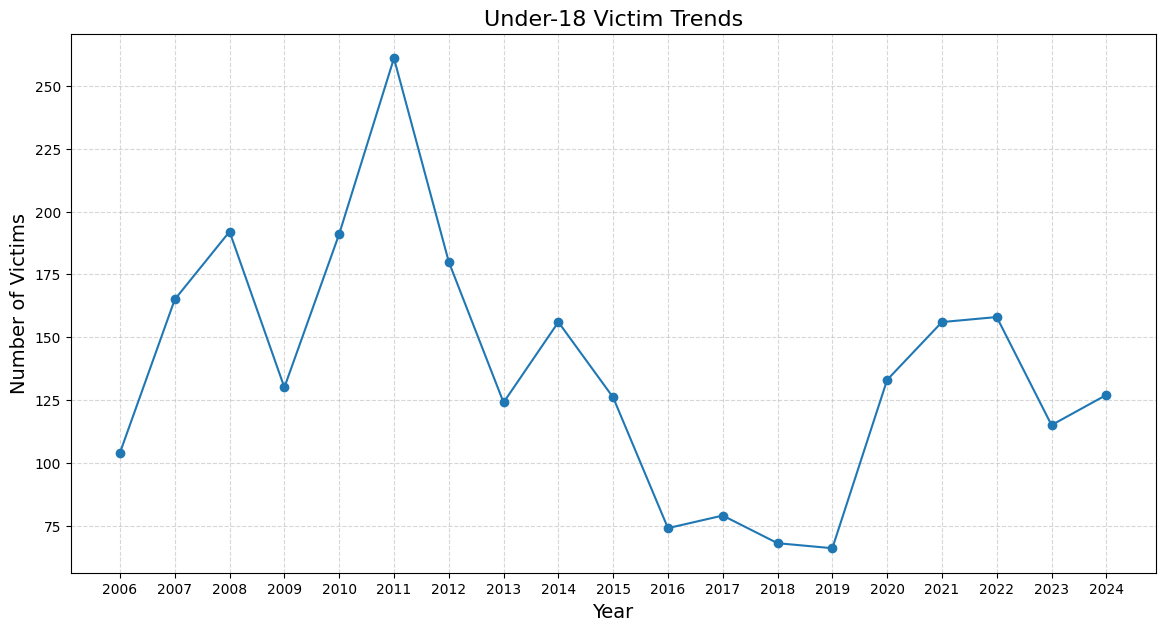

In [143]:
under18 = age_df[age_df['vic_age_group'] == '<18']
under18_trend = under18.groupby('year').size()

under18_trend.plot(
    kind = 'line',
    marker = 'o',
    figsize=(14, 7)
    # , color = ['skyblue'
    # ]
)

plt.title("Under-18 Victim Trends", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Victims", fontsize=14)

plt.xticks(all_years)

plt.grid(True, linestyle="--", alpha=0.5)


plt.show()

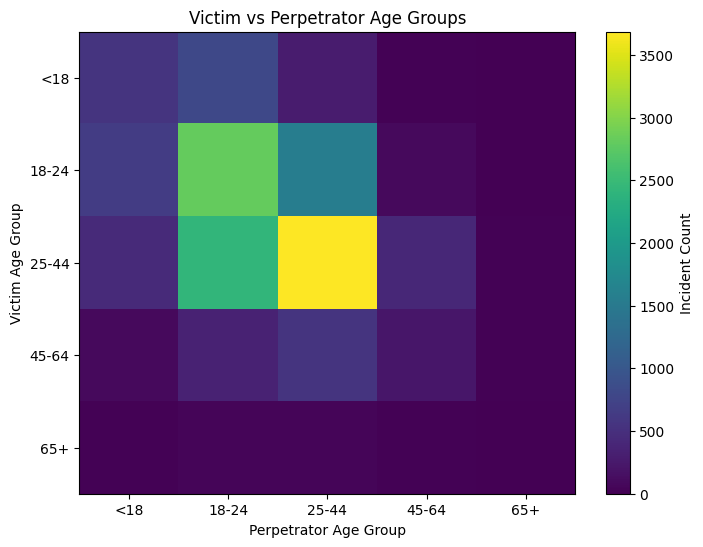

In [144]:
age_order = ['<18', '18-24', '25-44', '45-64', '65+']

age_relationship = pd.crosstab(
    age_df['vic_age_group'],
    age_df['perp_age_group']
)

# AGE INDEX AND COLUMNS OF THE RELATIONSHIP BETWEEN THE VICTIM AND PERPETRATOR
age_relationship = age_relationship.reindex(
    index = age_order,
    columns=age_order
)

plt.figure(figsize=(8,6))

plt.imshow(age_relationship,
    aspect='auto',
    # cmap='Blues'
)

plt.colorbar(label='Incident Count')

plt.xticks(
    range(len(age_relationship.columns)),
    age_relationship.columns
)
plt.yticks(
    range(len(age_relationship.index)),
    age_relationship.index
)

plt.title("Victim vs Perpetrator Age Groups")
plt.xlabel("Perpetrator Age Group")
plt.ylabel("Victim Age Group")

plt.show()